### **NPower Canada - Junior Data Analyst Team A / Course 8 - Visualization Tool Activity**
- Project Presenters: Group 1

     (Aafrin Yasmine Ansar, Alfian Pranoto, Brenda Baek, Komalben Patel, Omer Yalcin, Seid Hassen Yesuf)

- Subject: Visualization of a Kaggle Dataset using Matplotlib, Seaborn, and Plotly

- Goal: To visualize a Kaggle dataset using Matplotlib, Seaborn, and Plotly, and to compare the insights and effectiveness of each tool.

- Source: California Housing Prices https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

In [ ]:
# Import libraries
!pip install dash
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import plotly.express as px
import dash
from dash import Dash, dcc, html, Input, Output
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 10.2 MB/s eta 0:00:00


In [ ]:
# Download dataset
path = kagglehub.dataset_download("camnugent/california-housing-prices") + "/housing.csv"
df = pd.read_csv(path)
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Explore data set

feature report
1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
New Section
4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [ ]:
# Dataset summary
print(df.info())
df['ocean_proximity'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


The dataset has 20,640 rows. Only the 'total_bedrooms' column has missing values—207 rows in total, which is about 1% of the dataset.
This small amount of missing data is unlikely to affect the analysis.
For this project, however, we will fill the missing values with the mean to practice handling missing data.

In [ ]:
# Fill missing values with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Check dataset info after filling missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


We will examine the overall distribution and statistics of the dataset.

Although we could use **df.describe()** for summary statistics,
we will also practice creating various plots:
each column will be visualized with a histogram to see its distribution,
and a scatter plot to observe how each variable relates to the target variable, '**median_house_value**'.

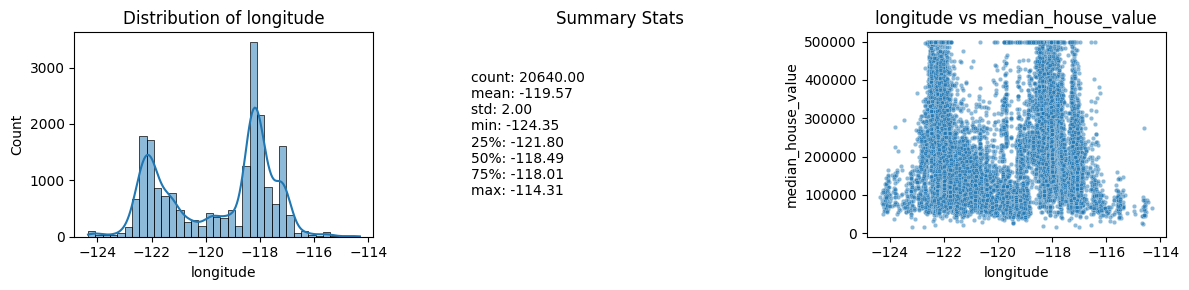

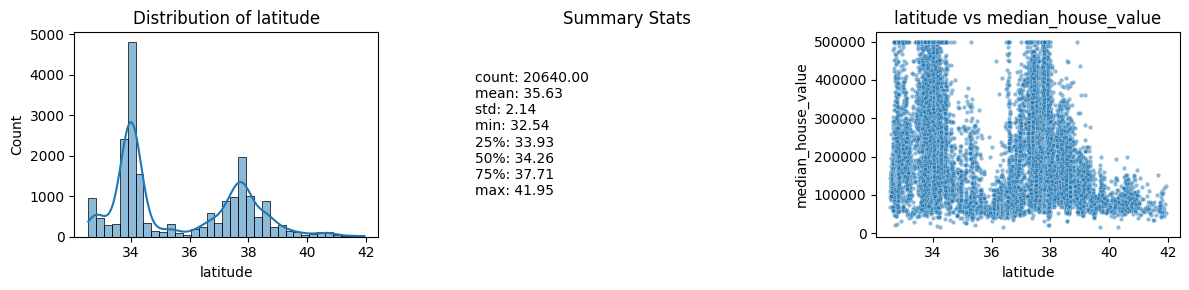

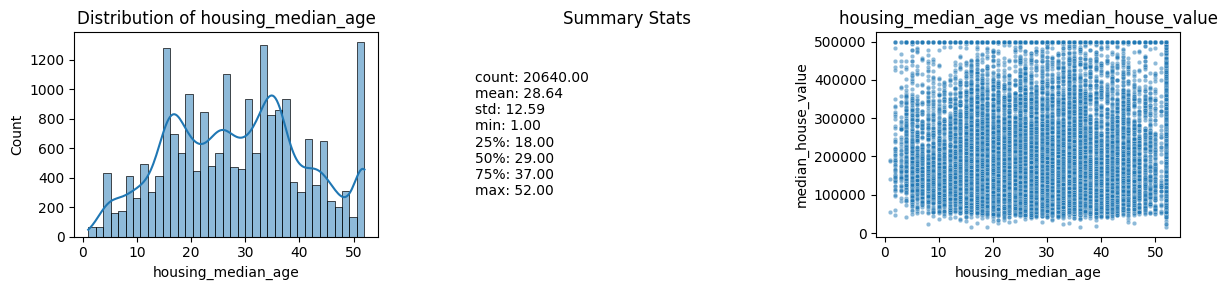

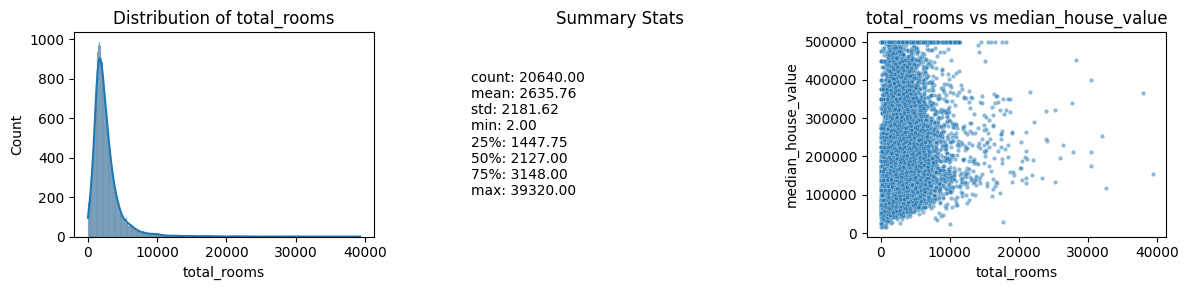

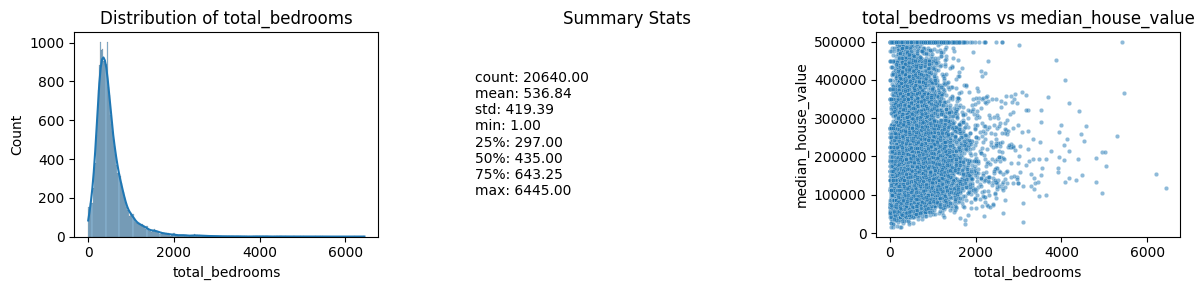

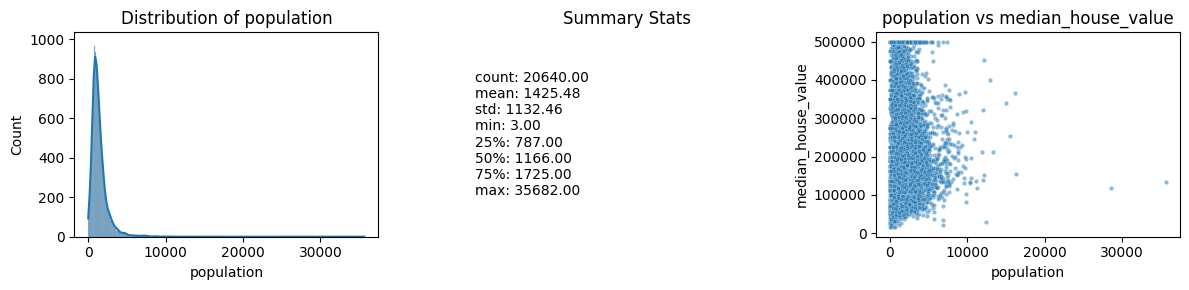

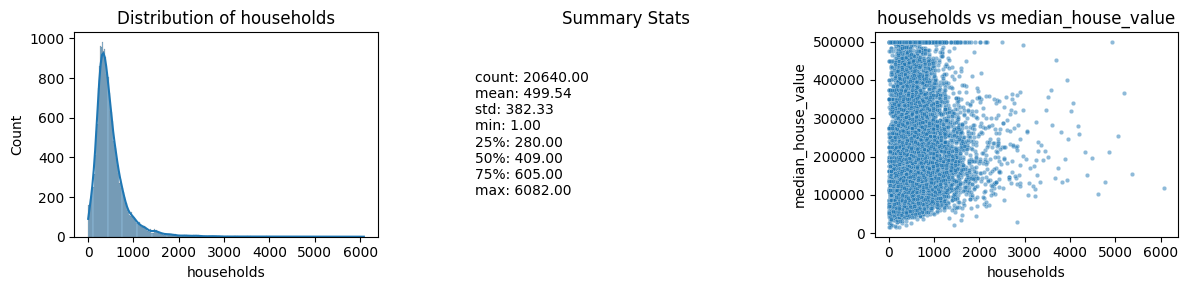

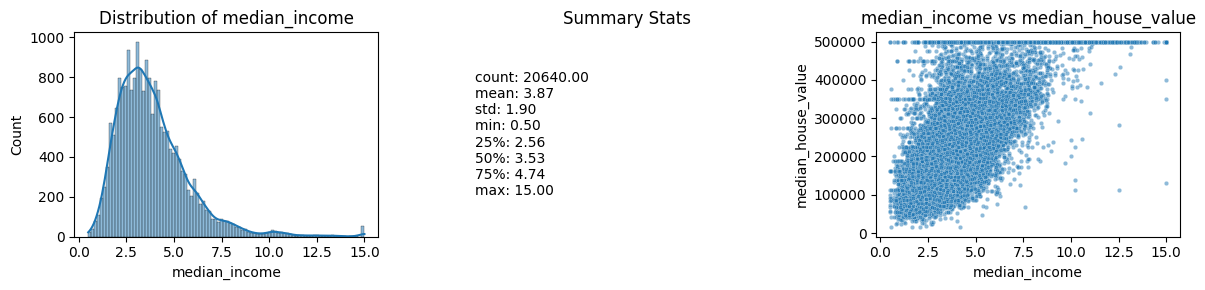

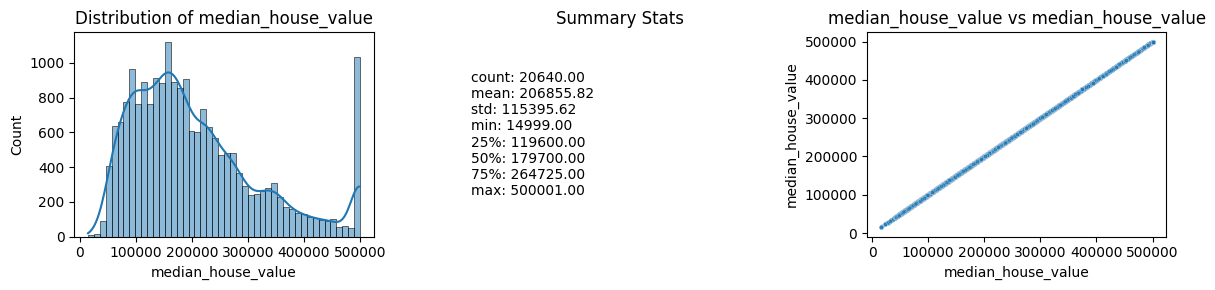

In [ ]:
# Target variable
target = "median_house_value"

# Select only numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
# Select only numeric columns (exclude target itself)
# num_cols = [col for col in df.select_dtypes(include=['int64','float64']).columns if col != target]


for col in num_cols:
    # Create subplots: 3 panels (histogram, stats, scatter)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))  # width slightly reduced

    # 1) Left: Histogram (smaller figure)
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    # 2) Middle: Summary statistics
    stats = df[col].describe()  # summary statistics
    axes[1].axis("off")
    text_str = "\n".join([f"{idx}: {val:.2f}" for idx, val in stats.items()])
    axes[1].text(0, 0.5, text_str, fontsize=10, va="center", ha="left")
    axes[1].set_title("Summary Stats")

    # 3) Right: Scatter plot with target (smaller points)
    sns.scatterplot(x=df[col], y=df[target], alpha=0.5, s=10, ax=axes[2])  # s=10 -> smaller points
    axes[2].set_xlabel(col)
    axes[2].set_ylabel(target)
    axes[2].set_title(f"{col} vs {target}")

    # Adjust layout
    plt.tight_layout()
    plt.show()

# 1. Scatter Plot Practice

After reviewing the overall dataset, the column that appears most suitable for this project is '**median_income**'.

Let's take a closer look at this data!

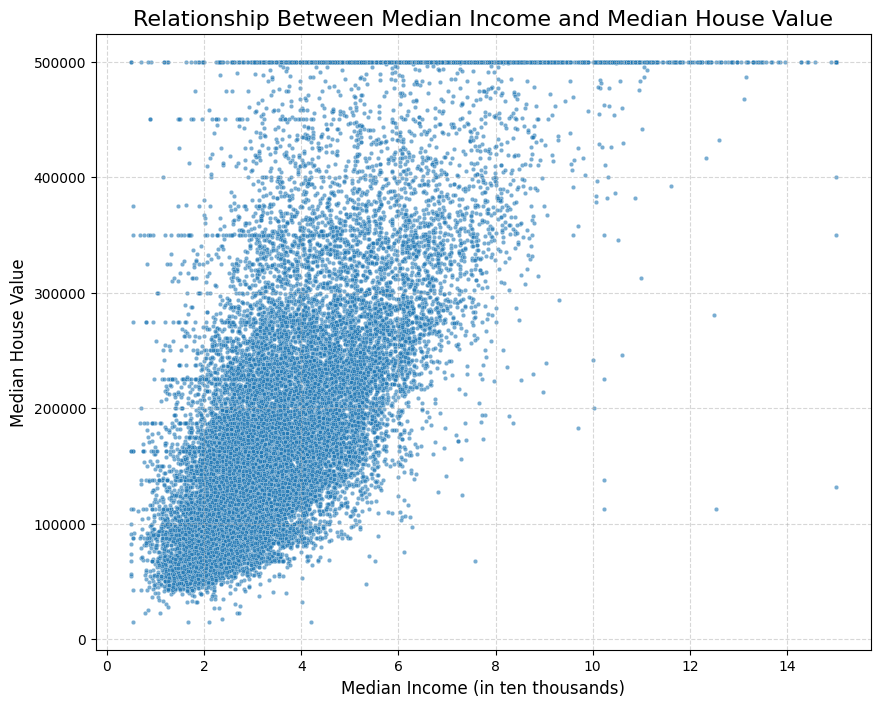

In [ ]:
# Set feature and target
# We will plot 'median_income' on the x-axis and 'median_house_value' on the y-axis
x_variable = 'median_income'
y_variable = 'median_house_value'

# Create the scatter plot using seaborn
# The 'data' parameter specifies the DataFrame to use
# Scatter plot: median_income vs median_house_value
plt.figure(figsize=(10, 8))   # Set the figure size for better visualization
sns.scatterplot(x=x_variable, y=y_variable, data=df, alpha=0.6, s=10)

# Add titles and labels for clarity
plt.title('Relationship Between Median Income and Median House Value', fontsize=16)
plt.xlabel('Median Income (in ten thousands)', fontsize=12)
plt.ylabel('Median House Value', fontsize=12)

# Add a grid for easier reading of the plot
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()

We will visualize the categorical variable '**ocean_proximity**' on the scatter plot.

It consists of 5 categories, and each category is represented with a different color.

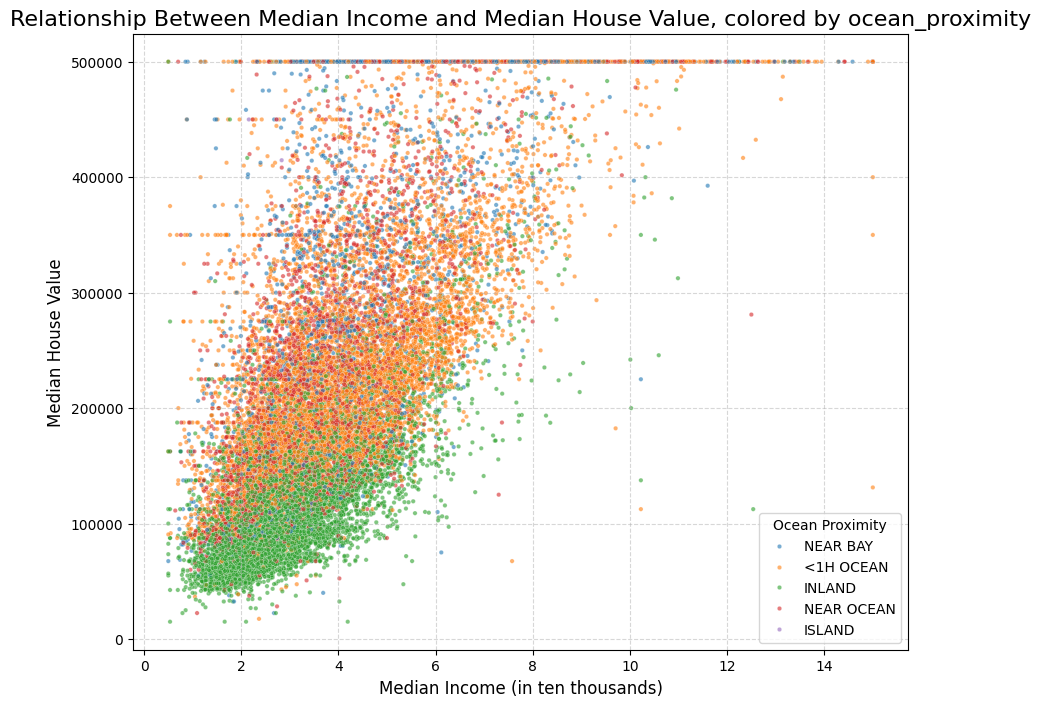

In [ ]:
# The 'hue' parameter can add an extra dimension by coloring points based on a categorical variable
plt.figure(figsize=(10, 8))
sns.scatterplot(x=x_variable, y=y_variable, data=df, alpha=0.6, s=10, hue='ocean_proximity')

plt.title('Relationship Between Median Income and Median House Value, colored by ocean_proximity', fontsize=16)
plt.xlabel('Median Income (in ten thousands)', fontsize=12)
plt.ylabel('Median House Value', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Ocean Proximity')
plt.show()


**Conclusion**

The scatter plot analysis demonstrates a clear positive correlation between **median household income** and **median house value** in California, showing that areas with higher income generally have higher property values.
Additionally, when coloring by **ocean proximity**, distinct clusters and patterns emerge, highlighting that location relative to the ocean is a key factor affecting house prices.
This analysis confirms that both income level and geographical location are important considerations in understanding property value trends.


# 2. Folium Map Plot Practice

In [ ]:
# Define the name of the folder you want to create
folder_name = 'assets'

# Check if the folder already exists to avoid an error. If it doesn't exist, create it
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' created successfully.")
else: print(f"Folder '{folder_name}' already exists.")

# Marker Cluster map for better visualization of many points ---
# Create a new base map, lat lon of california
california_center = [36.7783, -119.4179]
m1 = folium.Map(location=california_center, zoom_start=6, width=1000, height=800)

# Create a MarkerCluster object
marker_cluster = MarkerCluster().add_to(m1)

# Add all data points to the marker cluster
for index, row in df.iterrows():
    # Check for valid lat/lon
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']):
        # put the marker
        folium.Marker(
            location=[row['latitude'], row['longitude']]
        ).add_to(marker_cluster)

# Save the map to an HTML file
m1.save('assets/california_housing_marker_cluster.html')
m1

Folder 'assets' created successfully.


The map 'california_housing_marker_cluster.html' was created successfully.  
It groups nearby markers into clusters to make visualization of many data points easier.  
You can zoom in to see individual markers.

# 3. Dashboard Implementation Practice

In [ ]:
# Select only numeric columns (exclude 'longitude' and 'latitude')
numerical_columns = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in ['longitude', 'latitude']]

# Get unique 'ocean_proximity' values for the new dropdown
ocean_proximity_options = sorted(df['ocean_proximity'].unique())
ocean_proximity_options.insert(0, 'All') # Add an 'All' option for convenience

# Initialize the Dash app
app = Dash(__name__)

# Define the layout of the dashboard
app.layout = html.Div([
    html.H1("California Housing Price Analysis", style={'textAlign': 'center', 'color': '#333'}),

    html.Div([
        # New dropdown for filtering by ocean_proximity
        html.Div([
            html.H3("Select Ocean Proximity", style={'color': '#555'}),
            dcc.Dropdown(
                id='proximity-dropdown',
                options=[{'label': i, 'value': i} for i in ocean_proximity_options],
                value='All', # Set a default value
                clearable=False
            ),
        ], style={'width': '30%', 'display': 'inline-block', 'padding-left': '1%'})
    ], style={'padding': '20px', 'backgroundColor': '#f9f9f9', 'borderRadius': '10px'}),

    # Graph component to display the scatter plot
    html.H2("House Value Scatter Plot", style={'textAlign': 'center', 'marginTop': '40px'}),
    dcc.Graph(id='scatter-plot', style={'marginTop': '20px', 'width': '80%'}),

    html.Div([
        html.P("This dashboard displays the relationship between Median Income and Median House Value, filtered by ocean proximity.", style={'textAlign': 'center', 'color': '#777'})
    ]),

    # Use a new Plotly graph for the Choropleth map-like visualization
    html.H2("Geospatial Data Map", style={'textAlign': 'center', 'marginTop': '20px'}),
    dcc.Graph(id='map-plot', style={'marginTop': '20px', 'height': '80%', 'width': '80%'}),
])

# Define the callback function to update the scatter plot
@app.callback(
    Output('scatter-plot', 'figure'),
    [Input('proximity-dropdown', 'value')]
)
def update_scatter_graph(selected_proximity):
    """
    This function generates a scatter plot based on the user's dropdown selection and filters the data
    by the selected 'ocean_proximity'.
    """
    # Define the fixed x and y variables
    x_variable = 'median_income'
    y_variable = 'median_house_value'

    # Filter the DataFrame based on the selected ocean_proximity
    if selected_proximity == 'All':
        filtered_df = df
    else:
        filtered_df = df[df['ocean_proximity'] == selected_proximity]

    # Create the scatter plot using plotly.express
    fig = px.scatter(
        filtered_df,
        x=x_variable,
        y=y_variable,
        color='ocean_proximity',
        hover_data=filtered_df.columns, # Show all data on hover
        title=f'Relationship Between {x_variable.replace("_", " ").title()} and {y_variable.replace("_", " ").title()}'
    )

    # Update the plot layout for better readability
    fig.update_layout(
        xaxis_title=x_variable.replace("_", " ").title(),
        yaxis_title=y_variable.replace("_", " ").title(),
        title_x=0.5 # Center the title
    )

    return fig

# Define the callback function to update the map plot
@app.callback(
    Output('map-plot', 'figure'),
    [Input('proximity-dropdown', 'value')]
)
def update_map_graph(selected_proximity):
    """
    This function generates a map plot based on the user's dropdown selection and filters the data
    by the selected 'ocean_proximity'.
    """
    # Filter the DataFrame based on the selected ocean_proximity
    if selected_proximity == 'All':
        filtered_df = df
    else:
        filtered_df = df[df['ocean_proximity'] == selected_proximity]

    # Create the scatter mapbox plot, coloring by ocean proximity
    fig = px.scatter_mapbox(
        filtered_df,
        lat="latitude",
        lon="longitude",
        color="ocean_proximity",
        hover_data=["median_house_value", "median_income"],
        zoom=5,
        height=600,
        title="California Housing Data by Ocean Proximity"
    )

    # Use a custom mapbox style for better aesthetics
    fig.update_layout(mapbox_style="carto-positron")
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

    return fig

# Run the app
if __name__ == '__main__':
    app.run(debug=True)

<IPython.core.display.Javascript object>